# 06. Batch Normalization — Keras

Batch normalization standardises each layer's activations per mini-batch. It stabilises and speeds up training and adds a mild regularizing effect. We compare an MLP **with vs without** BN.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. Two models: plain vs BatchNorm

BN goes **between** the Dense layer and its activation — that's why we split the activation into a separate layer here.

In [5]:
def build(use_bn):
    keras.utils.set_random_seed(42)
    layers_list = [keras.Input(shape=(N_FEATURES,))]
    for units in (64, 64):
        layers_list.append(layers.Dense(units, use_bias=not use_bn))
        if use_bn:
            layers_list.append(layers.BatchNormalization())
        layers_list.append(layers.Activation("relu"))
    layers_list.append(layers.Dense(1, activation="sigmoid"))
    model = keras.Sequential(layers_list)
    model.compile(optimizer=keras.optimizers.SGD(0.05),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

hist_plain = build(False).fit(X_train, y_train, validation_data=(X_test, y_test),
                              epochs=100, batch_size=32, verbose=0)
hist_bn    = build(True ).fit(X_train, y_train, validation_data=(X_test, y_test),
                              epochs=100, batch_size=32, verbose=0)
print("Plain     final test acc = %.3f" % hist_plain.history["val_accuracy"][-1])
print("BatchNorm final test acc = %.3f" % hist_bn.history["val_accuracy"][-1])

Plain     final test acc = 0.862
BatchNorm final test acc = 0.805


## 5. Convergence comparison

With the same (deliberately modest) SGD learning rate, BN typically drives the loss down **faster** in the early epochs.

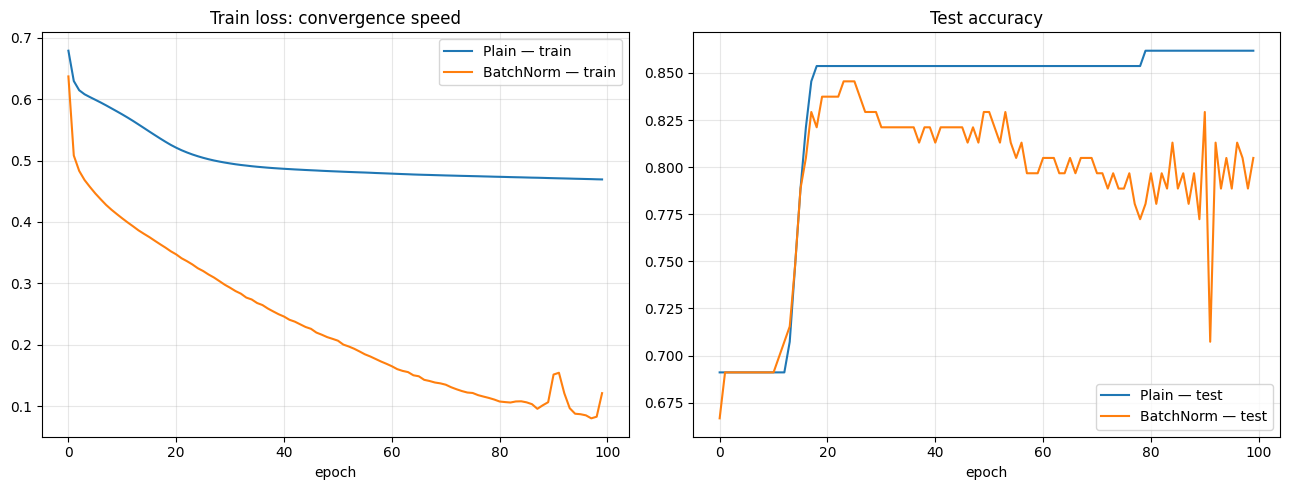

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(hist_plain.history["loss"], label="Plain — train")
ax[0].plot(hist_bn.history["loss"],    label="BatchNorm — train")
ax[0].set_title("Train loss: convergence speed")
ax[1].plot(hist_plain.history["val_accuracy"], label="Plain — test")
ax[1].plot(hist_bn.history["val_accuracy"],    label="BatchNorm — test")
ax[1].set_title("Test accuracy")
for a in ax: a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways
- BN normalises activations to zero-mean/unit-variance per batch, then rescales with two learned parameters (γ, β).
- Benefits: **faster convergence**, tolerance of higher learning rates, and a small regularizing effect from batch noise.
- It behaves differently in training vs inference (Keras handles this automatically — running statistics are used at test time).
- On tiny datasets the gain is modest, but the *shape* of the effect — faster early descent — is the lesson.
- **Next:** `07_dropout_keras` — the other classic regularizer.